# Classification

We've learned how to perform regression. Let's look into another machine learning algorithm. 

Let's assume you are building a system for admissions office for CAU. You have all the student records along with their results : admit/ deny. If you want to reverse engineer the system, do you think regression will do? 


Unfortunately, regression cannot predict binary values. Thus, we need different approach. 


## Logistic Regression Algorithm

Let's start with the classi algorithm for  classification: Logistic regression


Classification can predict discrete dependent variables. (these dependent variables are categorical values)  

For instance,case 1:  elephant, cat, horse, dog,... 
             case 2:  positive , negative 
    
For simplicity, for the time being, only consider the 2nd case: binary classification (case 1 is called multiclass classification) 


Can we predict the  dependent variable using two values? 

(Yes, we can)

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def sigmoid(x):
    a = []
    for item in x:
               #(the sigmoid function)
        a.append(1/(1+math.exp(-item)))
    return a

sigmoid function maps values between 0 and 1. If we can use this function in a smart way, we can build binary classification alborithm.  

In [3]:
x = np.arange(-10., 10., 0.2)

Let's plot how the graph looks like

In [4]:
y = sigmoid(x)

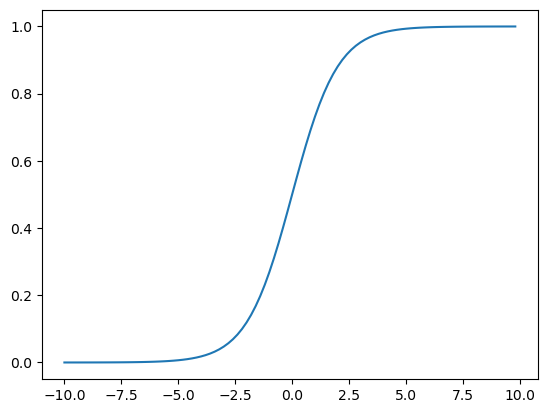

In [5]:
plt.plot(x,y)
plt.show()

## Hypothesis and Cost Function


Let's use our sigmoid function and build our hypothesis and define our cost function. 


### Hypothesis

Previously, in regression,  we learned the function below

 $h_θ(x)={θ}^T{x}=θ_0+θ_1x_1+θ_2x_2+⋯+θ_Kx_K$

For binary case, we simply have to use sigmoid function for mapping. (very simple)

 $h_θ(x)=\sigma ({θ}^T{x})$

The sigmoid function is defined as below

$\sigma(z) = {1\over 1+\exp(-z)}$

Hypothesis can be defined as below, the function states as follows. 

$$
{  h_\sigma(x) =
  \begin{cases}
    >0.5      & \quad \text{if }\theta^Tx>0\\
    <0.5  & \quad \text{if } \theta^Tx<0
  \end{cases}
}
$$



If you look carefully in the equation above, if the input (or weighted sum) is above 0 we can assign it to class 1 and vice versa. 
Here, the decision boundary becomes 0, which devides class 1 vs class 2. 

### Cost Function

Similar to regression, we can define coast function , and let the cost function minimized for learning weights. 

For simple, example, assume we have one datapoint for optimizing. 

$$
{  \text{cost} =
  \begin{cases}
    -\log(h_\theta(x))      & \quad \text{if }y=1\\
     -\log(1-h_\theta(x))   & \quad \text{if }y=0
  \end{cases}
}
$$

Accoring to the cost function, 

In binary class, label can be represented as 0 or 1. If the actual value was 0 and our prediction was 1 or vice versa, we need the cost function to be penalized. 

In above,  -log(h(x)) converges to 0 as h(x) gets close to 1, and gets to infinity as h(x) goest to 0. 
in the opposite case,  -log(1-h(x)) converges to 0 as the actual value is 0 and the prediction is 0, but goest to infinity if the prediction is 1. Thus, when our prediction is correct, the cost function gets close to 0. 






Can we express the above equation in a single line? 

## Another approach

Let's look again the hypothesis in our logistic regression. 

$h_θ(x)=\sigma({θ}^T{x})=\sigma(θ_0+θ_1x_1+θ_2x_2+⋯+θ_Kx_K)$


How do we fit the parameters if we are given with this model? 

To solve the problem, lets rely on probability and try to find $\theta$

Let's have our hypothesis below

$P(y = 1 | x; θ) = h_{θ}(x)$

For the opposite case

$P(y = 0 | x; θ) = 1-h_{θ}(x)$

We can combine these as below:

$P(y | x; θ) = (h_θ(x))^y(1 − h_θ(x))^{(1−y)}$


What if we have $m$ data samples? \
How can we define the likelihood? 

\begin{align} 
L(\theta)  &= p(Y | X; θ) \\
           &= \prod_i^m(y^{(i)} | x^{(i)};\theta) \\
           &= \prod_i^m (h_θ(x^{(i)}))^{y^{(i)}}(1 − h_θ(x^{(i)}))^{(1−y^{(i)})} 
\end{align}




In ML, we can maximize the likelihood directly, but for simplicity, we take the log and maximiz it. 

Let's take the logarithm

\begin{align} 
l(\theta)  &= \log L(\theta) \\
            &=\sum_i^m  y^{(i)} \log(h_θ(x^{(i)})) +  (1-y^{(i)})\log(1 − h_θ(x^{(i)}))
\end{align}

Can we see the difference between the cost function we had and the loglikelihood? 

maximizing log likelihood is exaclty same as minimizing the coas. 


maximizing  likelihood leads to minimizing the cost !!! 

How can we find suitable $\theta$ ?

We relax on GD

Now, les's check scikit learn

In [1]:
from sklearn.linear_model import LogisticRegression

pima indian diabetes 데이터를 사용하자. 

In [3]:
#import pandas
import pandas as pd
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("diabetes.csv", header=0, names=col_names)
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#split dataset in features and target variable
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

In [5]:
X

,pregnant,insulin,bmi,age,glucose,bp,pedigree
0,6,0,33.6,50,148,72,0.627
1,1,0,26.6,31,85,66,0.351
2,8,0,23.3,32,183,64,0.672
3,1,94,28.1,21,89,66,0.167
4,0,168,43.1,33,137,40,2.288
...,...,...,...,...,...,...,...
763,10,180,32.9,63,101,76,0.171
764,2,0,36.8,27,122,70,0.340
765,5,112,26.2,30,121,72,0.245
766,1,0,30.1,47,126,60,0.349


traing set 과 test set을 나누자.

In [6]:
from sklearn.model_selection  import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [7]:
logreg = LogisticRegression()

logreg.fit(X_train,y_train)

y_pred=logreg.predict(X_test)

c:\Users\baedo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0])

In [9]:
y_test

661    1
122    0
113    0
14     1
529    0
      ..
366    1
301    1
382    0
140    0
463    0
Name: label, Length: 192, dtype: int64

confusion matrix 란? 

## 모델 평가

confusion matrix 구하기 

In [10]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[117,  13],
       [ 24,  38]])

confusion matrix 시각화

In [11]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 427.9555555555555, 'Predicted label')

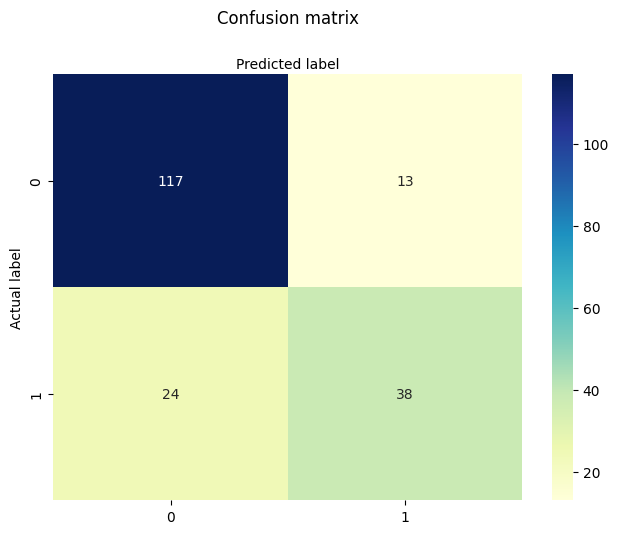

In [12]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
# label0은 잘 맞추는데 label1은 잘 못맞춘다. label0으로 맞추려는 경향이 있다. 이유는 data frequency 때문이다.(bias)
# 의료에서는 암이 있는데 없다고 진단하는게 훨씬 위험하다.
# 해결책 3가지
# undersampling(암200명, 암아님 1000명이 있으면 암아님에서 200명 뽑음)
# oversampling(암200명, 암아님 1000명이 있으면 암 그룹을 5배로 증폭
# likelihood(weight)